In [15]:
# import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [16]:
# Create a sample dirty dataset
data={'name':[' ali ', 'Sara', ' reza', None, 'Mina '], 
      'subject':[' Math ', 'maths', 'English', 'math','english'],
      'score':[15,None,18,12,None]
     }
#Convert To DataFrame
df=pd.DataFrame(data)

# Save to Csv (this will create the file)
df.to_csv('students_dirty.csv',index=False)

# Just to confirm it's created 
print('students_dirty.csv file created successfully.')

students_dirty.csv file created successfully.


In [17]:
# Copy original for comparison
df_before = df.copy()

#Standardize subject name in both df_before and df_after
for dataframe in [df_before, df]:
    #Remove extra spaces and unify case 
    dataframe['name'] = dataframe['name'].str.strip().str.title()
    dataframe['subject']= dataframe['subject'].str.strip().str.lower()
    #Replace similar subject names
    dataframe['subject'] = dataframe['subject'].replace({'maths':'math'})
df_before.head()
#show first few rows
df.head()

,name,subject,score
0,Ali,math,15.0
1,Sara,math,NaN
2,Reza,english,18.0
3,None,math,12.0
4,Mina,english,NaN


In [19]:
#Check data structure and types
df.info() 

#Fill missing scores in df with mean per subject
df['score']= df.groupby('subject')['score'].transform(lambda x:x.fillna(x.mean()))

#Drop rows where name is missing
df=df.dropna(subset=['name'])

#Check number of missing values in each column
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   name     4 non-null      object 
 1   subject  5 non-null      object 
 2   score    5 non-null      float64
dtypes: float64(1), object(2)
memory usage: 252.0+ bytes


name       0
subject    0
score      0
dtype: int64

In [21]:
#Calculate average score
before_avg= df_before.groupby('subject')['score'].mean()
after_avg = df.groupby('subject')['score'].mean()

print('Average before cleaning:')
print(before_avg)
print('\nAverage after cleaning:')
print(after_avg)

Average before cleaning:
subject
english    18.0
math       13.5
Name: score, dtype: float64

Average after cleaning:
subject
english    18.00
math       14.25
Name: score, dtype: float64


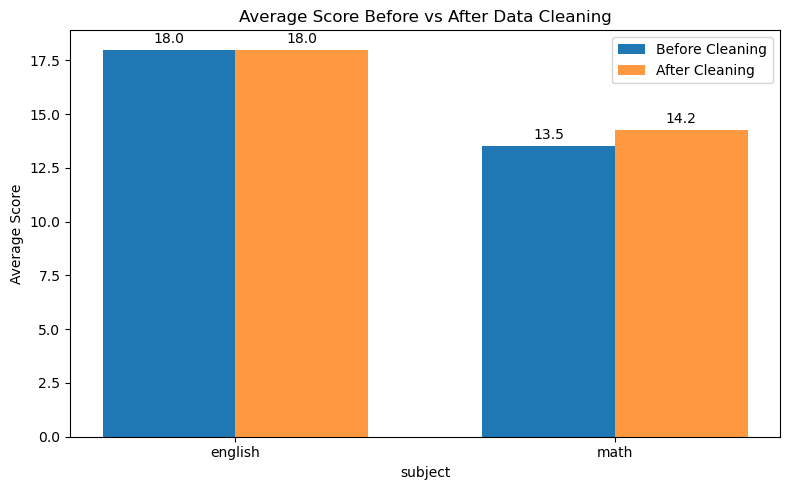

In [22]:
# Align subjects so both series have the same order
subjects = before_avg.index.union(after_avg.index)
before_aligned = before_avg.reindex(subjects).fillna(0)
after_aligned = after_avg.reindex(subjects).fillna(0)

# x positions for the bars
x=np.arange(len(subjects))
width=0.35

#Create figure and bars
plt.figure(figsize=(8,5))
bars1=plt.bar(x - width/2, before_aligned.values,
        width=width, label='Before Cleaning')
bars2=plt.bar(x + width/2, after_aligned.values,
        width=width,label='After Cleaning',alpha=0.8)

#Set x-axis labels and title
plt.xticks(x, subjects)
plt.title('Average Score Before vs After Data Cleaning')
plt.xlabel('subject')
plt.ylabel('Average Score')
plt.legend()

#Add values above bars
def annotate_bars(bars):
    for bar in bars:
        height=bar.get_height()
        plt.annotate(f'{height:.1f}', 
                     xy=(bar.get_x()+
                         bar.get_width()/2, height),
                     xytext=(0,3), #vertical offset
                     textcoords='offset points', ha='center',
                     va='bottom')
annotate_bars(bars1)
annotate_bars(bars2)
plt.tight_layout()
plt.show()


Data Cleaning Report
--------------------
1. Removed extra spaces and unified letter 
cases in 'name' and 'subject' columns.
2. Replaced 'maths' with 'math' to 
standardize subject names.
3. Found 3 missing values in 'score' and 1 missing 'name'.
4. Filled missing scores with the mean of each subject.
5. Removed rows where 'name' was missing.
6. Average scores slightly increased after data cleaning, 
showing the impact of missing value imputation.